#Introduzione e riferimenti
In questa sezione sono spiegate le principali scelte compiute e sono citati i riferimenti. Nel corso del lavoro e delle implementazioni sono documentate tutte le componenti del sistema costruito ed inoltre sono stampati a schermo alcuni passaggi così da vedere come procede l'elaborazione del flusso di dati.



**Riferimento principale**: Dalal, N., & Triggs, B. (2005). Histograms of oriented gradients for human detection. CVPR.<br>

**Dataset**<br>
Per gli esempi positivi (volti) è stato scelto Workspace_lfw_people da Scikit-learn perchè è facile da usare e contiene immagini di volti ritagliate. Per quanto riguarda, invece, gli esempi negativi (non-volti), sono stati creati estraendo patch casuali da immagini generiche scaricate da url e, come fallback, da skimage.data.<br>
L'idea di usare patch casuali da immagini come negativi è una pratica comune quando non si dispone di un dataset specifico.

**HOG (histogram of oriented gradients)**
È l'algoritmo cardine di questo lavoro ed è stato scelto per la sua efficacia nel descrivere forme basate su gradienti, per la sua relativa invarianza a cambiamenti di illuminazione e per la sua efficienza computazionale rispetto a metodi più complessi (deep learning).<br>
Riferimento: Dalal, N., & Triggs, B. (2005). Histograms of oriented gradients for human detection. CVPR.

**Modello di classificazione**
LinearSVC (Linear Support Vector Classifier) è stato scelto come modello di classificazione data la sua efficienza con feature ad alta dimensionalità (come HOG) e per le buone performance generalizzate. È difatti adatto per sistemi con risorse limitate.<br>
L'uso di SVM lineari con HOG è un approccio classico e ben documentato in letteratura per la rilevazione di oggetti.

**Image pyramid**<br>
Questa è la tecnica scelta ed implementata per la gestione della rilevazione di volti a diverse scale.<br>
Il parametro scale_factor controlla il passo tra le scale.

**Sliding window**<br>
È un approccio standard per la rilevazione di oggetti (e volti) in cui un classificatore analizza piccole porzioni (finestre) dell'immagine.<br>
Il parametro step_size risulta cruciale per il trade-off tra accuratezza e velocità.

**Non-maximum suppression (NMS)**<br>
Questo algoritmo è essenziale per unire rilevazioni multiple e sovrapposte dello stesso volto basandosi sugli score del classificatore e sulla sovrapposizione (IoU).<br>
Nell'applicazione di questa metodologia, la decision_function dell'SVM fornisce uno score e poi una soglia su questo score permette di controllare il trade-off tra falsi positivi e falsi negativi.
Riferimento: Neubeck, A., & Van Gool, L. (2006). Efficient non-maximum suppression. ICPR.

**Osservazione**<br>
Il rilevatore costruito, intrinsecamente, non è invariante alla rotazione nel piano dell'immagine.

**Ricerca bibliografica**<br>
- Per HOG<br>
Dalal, N., & Triggs, B. (2005). Histograms of oriented gradients for human detection. IEEE Conference on Computer Vision and Pattern Recognition (CVPR).
- Per SVM<br>
Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine learning.
- Approccio classico per face detection<br>
Viola, P., & Jones, M. (2001). Rapid object detection using a boosted cascade of simple features. IEEE CVPR.
- Un lavoro influente su HOG e sui modelli deformabili<br>
Felzenszwalb, P. F., Girshick, R. B., McAllester, D., & Ramanan, D. (2009). Object detection with discriminatively trained part-based models. IEEE Transactions on Pattern Analysis and Machine Intelligence (TPAMI).
- Per NMS<br>
Neubeck, A., & Van Gool, L. (2006). Efficient non-maximum suppression. International Conference on Pattern Recognition (ICPR).

#1 Import librerie e costanti globali
In questa sezione viene preparato l'ambiente di lavoro importando tutte le librerie e funzioni necessarie per costruire, addestrare e valutare il sistema di rilevamento volti. Inoltre vengono definiti i parametri fondamentali per l'estrazione delle caratteristiche HOG (Histogram of Oriented Gradients) da patch di immagini e viene calcolata la dimensione del vettore di caratteristiche HOG risultante:
- PATCH_SIZE<br>
Dimensione standard (altezza e larghezza) in pixel delle porzioni di immagine (patch) che verranno analizzate. Il sistema cercherà volti o non-volti in patch di questa dimensione.
- HOG_ORIENTATIONS<br>
Numero di bin di orientamento dei gradienti. Per ogni cella dell'immagine verrà calcolato un istogramma dei gradienti e tali gradienti sono raggruppati in diverse direzioni principali.
- HOG_PIXELS_PER_CELL<br>
Dimensione in pixel di ogni cella. La patch viene suddivisa in celle più piccole, e per ognuna di queste verrà calcolato un istogramma degli orientamenti dei gradienti.
- HOG_CELLS_PER_BLOCK<br>
Numero di gruppi di celle che formano un blocco. I blocchi verranno usati per la normalizzazione del contrasto locale, il che rende le feature HOG più robuste a variazioni di illuminazione.
- HOG_FEATURE_SIZE<br>
Lunghezza totale del vettore di caratteristiche HOG che verrà estratto da una singola patch di PATCH_SIZE

In [122]:
#import librerie
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from io import BytesIO

#import da Scikit-learn
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline #per la pipeline
from sklearn.base import BaseEstimator, TransformerMixin #per trasformatori custom
from sklearn.metrics import confusion_matrix
from skimage import data, color, feature, transform, exposure
from sklearn.model_selection import learning_curve

#import per download immagini
import requests
from PIL import Image

#import per tuning
from scipy.stats import loguniform

#definizione costanti globali
PATCH_SIZE = (80, 80)  #altezza e larghezza della patch
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)

#calcolo della dimensione del vettore di caratteristiche HOG
HOG_FEATURE_SIZE = (
    (PATCH_SIZE[0] // HOG_PIXELS_PER_CELL[0] - HOG_CELLS_PER_BLOCK[0] + 1) *
    (PATCH_SIZE[1] // HOG_PIXELS_PER_CELL[1] - HOG_CELLS_PER_BLOCK[1] + 1) *
    HOG_CELLS_PER_BLOCK[0] * HOG_CELLS_PER_BLOCK[1] * HOG_ORIENTATIONS
)
print(f"Dimensione della patch: {PATCH_SIZE}")
print(f"Dimensione attesa del vettore di caratteristiche HOG: {HOG_FEATURE_SIZE}")


#riproducibilità (i random_state sono esplicitati manualmente ogni volta)
import random
random.seed(1996)
np.random.seed(1996)

Dimensione della patch: (80, 80)
Dimensione attesa del vettore di caratteristiche HOG: 2916


#2 Costruzione funzioni utili
In questa sezione vengono costruite le funzioni load_positive_samples, download_image, get_random_patches e load_negative_samples. Queste saranno utili a fornire le patch di immagini grezze, che saranno poi l'input per la pipeline.<br>

Per addestrare un classificatore di volti, sono necessari campioni positivi (che contengono volti) e negativi (che non contengono volti). Quindi verrà usato il dataset Labeled Faces in the Wild (LFW) per i campioni positivi, disponibile tramite Scikit-learn, invece per i campioni negativi verranno scaricate alcune immagini generiche da internet che non contengono volti e da cui saranno estratte patch casuali.

###2.1 load_positive_samples
Questa funzione ha lo scopo di caricare e preparare i campioni di immagini che contengono volti (campioni positivi). Tali campioni verranno usati per addestrare il modello nel riconoscimento di un volto.

In [123]:
def load_positive_samples(num_samples=1500):
    """
    Carica e pre-processa i campioni positivi (volti) dal dataset LFW.
    Restituisce patch in scala di grigi della PATCH_SIZE specificata nella sezione precedente.
    """
    print(f"Caricamento di circa {num_samples} campioni positivi (volti)...")
    lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4, color=False)

    positive_patches = []
    for image in lfw_people.images:
        #immagini LFW già abbastanza centrate sui volti quindi bisogna ridimensionare alla PATCH_SIZE
        resized_face = transform.resize(image, PATCH_SIZE, anti_aliasing=True, mode='reflect')
        positive_patches.append(resized_face)
        if len(positive_patches) >= num_samples:
            break

    if not positive_patches:
        raise ValueError("Nessun campione positivo caricato. Controllare i parametri di fetch_lfw_people o la connessione.")

    print(f"Caricati {len(positive_patches)} campioni positivi.")
    return np.array(positive_patches)

###2.2 download_image
Questa funzione è utile per scaricare un'immagine da un indirizzo web (url) specificato.

In [124]:
def download_image(url):
    """Scarica un'immagine da un url."""
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        return img
    except requests.exceptions.RequestException as e:
        print(f"Errore download {url}: {e}")
        return None


###2.3 get_random_patches
Questa funzione estrae un numero specificato di piccole porzioni (patch) casuali da un'immagine più grande. Inoltre, tali patch sono prese casualmente ed in scala di grigi da immagini più grandi. Questa funzione sarà utile, ad esempio, per generare campioni negativi per l'addestramento del classificatore.

In [125]:
def get_random_patches(image, patch_size_tuple, num_patches_to_extract):
    """
    Estrae patch casuali da un'immagine e converte l'immagine in scala di grigi se necessario.
    """
    if image is None:
        return []

    img_array = np.array(image)
    #conversione a scala di grigi
    if img_array.ndim == 3:
        if img_array.shape[2] == 3: #RGB
            img_array = color.rgb2gray(img_array)
        elif img_array.shape[2] == 4: #RGBA
            img_array = color.rgb2gray(color.rgba2rgb(img_array))

    if img_array.ndim != 2: #deve essere 2D (scala di grigi)
        print(f"Attenzione: immagine non convertita correttamente a scala di grigi. Shape: {img_array.shape}")
        return []

    patches_list = []
    img_h, img_w = img_array.shape
    patch_h, patch_w = patch_size_tuple

    if img_h < patch_h or img_w < patch_w:
        return [] #immagine troppo piccola

    for _ in range(num_patches_to_extract):
        x = random.randint(0, img_w - patch_w)
        y = random.randint(0, img_h - patch_h)
        patch = img_array[y:y + patch_h, x:x + patch_w]
        patches_list.append(patch)
    return patches_list


###2.4 load_negative_samples
Questa funzione ha il compito di raccogliere un set di campioni negativi, ovvero patch di immagini che non contengono volti. Tali campioni saranno essenziali per addestrare il modello a distinguere correttamente tra ciò che è un volto e ciò che non lo è. Questa funzione è progettata per essere robusta nel raccogliere un dataset diversificato e scelto di campioni negativi.<br>
più precisamente, l'obiettivo è quello di raccogliere un numero specificato (num_target_patches, di default 2000) di piccole patch di immagini (della dimensione patch_size_tuple, che è definita globalmente come PATCH_SIZE) che non contengano volti umani. Queste patch serviranno come esempi di non-volto durante l'addestramento del classificatore. Per fare ciò vengono usate due fonti:una fonte primaria (url) ed una fonte di fallback (skimage.data).<br>
<br>
Osservazione sull'azione della fonte di fallback: se non riesce a ottenere abbastanza patch dagli url (ad esempio, a causa di errori di download o perché le immagini non sono adatte), utilizza un set di immagini standard fornite dalla libreria skimage.data (come data.camera(), data.coffee(), data.brick(), ecc.).

In [126]:
def load_negative_samples(num_target_patches=2000, patch_size_tuple=PATCH_SIZE):
    """
    Carica campioni negativi (assenza di volti) scaricando immagini (paesaggi, oggetti e animali).
    Estrae patch casuali in scala di grigi della patch_size_tuple specificata.
    """
    print(f"Caricamento di circa {num_target_patches} campioni negativi (non-volti)...")
    image_urls = [
        "https://images.pexels.com/photos/257360/pexels-photo-257360.jpeg",
        "https://images.pexels.com/photos/326055/pexels-photo-326055.jpeg",
        "https://images.pexels.com/photos/417074/pexels-photo-417074.jpeg",
        "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg",
        "https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg",
        "https://images.pexels.com/photos/3408744/pexels-photo-3408744.jpeg",
        "https://images.pexels.com/photos/206359/pexels-photo-206359.jpeg",
        "https://images.pexels.com/photos/1287145/pexels-photo-1287145.jpeg",
        "https://images.pexels.com/photos/3225517/pexels-photo-3225517.jpeg",
        "https://images.pexels.com/photos/210243/pexels-photo-210243.jpeg",
        "https://www.scienzainrete.it/files/styles/molto_grande/public/francesco-ungaro-primate.jpg?itok=0e2lccD7",
        "https://www.zoodipistoia.it/wp-content/uploads/2022/02/atf_mobile_animali.jpg",
        "https://www.alacroma.it/wp-content/uploads/2020/08/Animali-esotici-in-condominio-1200x900.jpg",
        "https://imgcom.masterd.es/50/wp-content/uploads/2021/03/animali-esotici-domestici.jpg",
        "https://assets-eu-01.kc-usercontent.com/787a0907-db8e-01b4-1d53-09d7e342892f/2659c6c2-ec8e-41a4-81b4-6a6629d3e52c/Hund.jpg?w=562&fm=webp&lossless=0&q=75",
        "https://www.dobredog.it/wp-content/uploads/4303.0.982933262-ktZH-U432508659389837KF-1224x916@Corriere-Web-Sezioni-593x443-1.jpg",
        "https://buonenotizie.it/wp-content/uploads/2021/04/panda-3857754_1920.jpg",
        "https://static.tecnichenuove.it/animalidacompagnia/2022/03/animali-da-compagnia-quali-sono.jpg",
        "https://www.bostonextend.com/wp-content/uploads/2024/03/tigre-del-bengala.jpg",
        "https://www.immobiliare.it/news/app/uploads/2023/06/Quali-animali-non-sono-considerati-domestici-e-non-si-possono-tenere-in-casa.jpeg",
        "https://www.changethefuture.it/assets/uploads/2020/05/animali-selvatici.jpg",
        "https://static2-living.corriereobjects.it/wp-content/uploads/2024/12/00-livingcorriere-regalo-natale-2024.jpg.webp?v=1733834200",
        "https://c8.alamy.com/compit/2f3a6y1/set-di-oggetti-semplici-per-la-casa-isolato-su-nero-2f3a6y1.jpg",
        "https://www.clever.it/media/wysiwyg/news/sala-hobby-trasformabile-im22-07-clever.jpg",
        "https://www.harte.it/wp-content/uploads/2022/10/Copertina.png",
        "https://www.ikea.com/images/camera-da-letto-completamente-arredata-con-finestre-alte-com-fc397d67e269718164f4ac0d15927162.jpg?f=xl",
        "https://cdn.cosedicasa.com/wp-content/uploads/webp/2013/08/vista1-zona-conversazione.webp"
    ]

    all_negative_patches = []
    patches_per_url_image = num_target_patches // len(image_urls) + 5 if image_urls else num_target_patches # +5 per margine

    downloaded_count = 0
    for url in image_urls:
        if len(all_negative_patches) >= num_target_patches:
            break
        print(f"Download per negativi da: {url}")
        img = download_image(url)
        if img:
            downloaded_count +=1
            patches_from_this_img = get_random_patches(img, patch_size_tuple, patches_per_url_image)
            all_negative_patches.extend(patches_from_this_img)
            print(f"  Estratte {len(patches_from_this_img)} patch. Totale negativi: {len(all_negative_patches)}")

    #fallback a skimage.data
    if len(all_negative_patches) < num_target_patches:
        print("Pochi campioni negativi da URL, uso fallback da skimage.data...")
        skimage_fallback_imgs = {
            'camera': data.camera(),
            'coffee': data.coffee(),
            'brick': data.brick(),
            'grass': data.grass(),
            'horse': data.horse()
        }

        needed_patches = num_target_patches - len(all_negative_patches)
        patches_per_skimage_img = needed_patches // len(skimage_fallback_imgs) + 1 if skimage_fallback_imgs else needed_patches

        for name, skimage_img_data in skimage_fallback_imgs.items():
            if len(all_negative_patches) >= num_target_patches:
                break
            print(f"  Estrazione da skimage.data.{name}()")
            patches_from_this_img = get_random_patches(skimage_img_data, patch_size_tuple, patches_per_skimage_img)
            all_negative_patches.extend(patches_from_this_img)
            print(f"    Estratte {len(patches_from_this_img)} patch. Totale negativi: {len(all_negative_patches)}")

    if not all_negative_patches:
        raise ValueError("ERRORE: Nessun campione negativo caricato. Impossibile procedere.")

    random.shuffle(all_negative_patches) #mischia per evitare bias di sorgente
    final_patches = np.array(all_negative_patches[:num_target_patches])
    print(f"Caricati {len(final_patches)} campioni negativi.")
    return final_patches

#3 Caricamento esempi, creazione classe HOGTransformer, costruzione datasetcompleto e dei set di training e test
In questa sezione vengono fatte diverse operazioni cruciali:
1. vengono caricati gli esempi positivi (immagini di volti) e negativi (immagini senza volti) in modo che ci sia un numero bilanciato di entrambi.
2. viene definita una classe chiamata HOGTransformer. Tale classe è progettata per essere utilizzata all'interno di una pipeline di Scikit-learn come un trasformatore personalizzato ed il suo scopo principale è quello di estrarre le caratteristiche HOG (Histogram of Oriented Gradients) da un insieme di patch di immagini.
Dunque, la classe HOGTransformer incapsula la logica per l'estrazione delle caratteristiche HOG in un formato compatibile e funzionale con le pipeline di Scikit-learn.
3. Si effettua la preparazione dei dati (patch di immagini e le loro etichette) per il successivo addestramento. Più precisamente viene prima "assemblato" il dataset completo e poi viene "splittato" in training test e test set


###3.1 Caricamento esempi

In [127]:
positive_samples = load_positive_samples()
#caricare un numero simile di campioni negativi e positivi
num_negative_to_load = len(positive_samples) if positive_samples.size > 0 else 1500
negative_samples = load_negative_samples(num_target_patches=num_negative_to_load)

#controllo caricamento esempi
if positive_samples.size == 0 or negative_samples.size == 0:
    raise ValueError("Errore nel caricamento dei campioni positivi o negativi. Controllare i log.")

print(f"Forma campioni positivi: {positive_samples.shape}")
print(f"Forma campioni negativi: {negative_samples.shape}")


Caricamento di circa 1500 campioni positivi (volti)...
Caricati 1140 campioni positivi.
Caricamento di circa 1140 campioni negativi (non-volti)...
Download per negativi da: https://images.pexels.com/photos/257360/pexels-photo-257360.jpeg
  Estratte 47 patch. Totale negativi: 47
Download per negativi da: https://images.pexels.com/photos/326055/pexels-photo-326055.jpeg
  Estratte 47 patch. Totale negativi: 94
Download per negativi da: https://images.pexels.com/photos/417074/pexels-photo-417074.jpeg
  Estratte 47 patch. Totale negativi: 141
Download per negativi da: https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg
  Estratte 47 patch. Totale negativi: 188
Download per negativi da: https://images.pexels.com/photos/45201/kitty-cat-kitten-pet-45201.jpeg
  Estratte 47 patch. Totale negativi: 235
Download per negativi da: https://images.pexels.com/photos/3408744/pexels-photo-3408744.jpeg
  Estratte 47 patch. Totale negativi: 282
Download per negativi da: https://images.pexels

###3.2 Transformer HOG

In [128]:
class HOGTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, orientations=HOG_ORIENTATIONS,
                 pixels_per_cell=HOG_PIXELS_PER_CELL,
                 cells_per_block=HOG_CELLS_PER_BLOCK,
                 transform_sqrt=True,
                 feature_vector=True,
                 block_norm='L2-Hys'):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.transform_sqrt = transform_sqrt
        self.feature_vector = feature_vector
        self.block_norm = block_norm

    def fit(self, X, y=None):
        #per HOG non c'è un fit specifico sui dati di training (parametri predefiniti)
        return self

    def transform(self, X_patches, y=None):
        #X_patches è atteso come un array di patch di immagini (n_samples, altezza, larghezza)
        #ogni patch deve essere già in scala di grigi e della PATCH_SIZE attesa.
        print(f"  HOGTransformer: trasformazione di {len(X_patches)} patch...")
        hog_features_list = []
        for patch in X_patches:
            #validazione dimensione patch
            if patch.shape != PATCH_SIZE:
                print(f"    Attenzione: patch di dimensione inattesa {patch.shape} rilevata in HOGTransformer.")

            current_hog_features = feature.hog(patch,
                                               orientations=self.orientations,
                                               pixels_per_cell=self.pixels_per_cell,
                                               cells_per_block=self.cells_per_block,
                                               block_norm=self.block_norm,
                                               visualize=False,
                                               transform_sqrt=self.transform_sqrt,
                                               feature_vector=self.feature_vector)
            hog_features_list.append(current_hog_features)

        transformed_features = np.array(hog_features_list)
        print(f"  HOGTransformer: caratteristiche estratte con forma {transformed_features.shape}")
        return transformed_features

###3.3 Dataset completo e divisione in training set e test set

In [129]:
#creazione del dataset completo di patch (X_data_patches) e etichette (y_data_labels)
#NOTA PER IL LETTORE: le patch sono già state caricate e sono in positive_samples e negative_samples
X_data_patches = np.concatenate((positive_samples, negative_samples), axis=0)
y_data_labels = np.hstack((np.ones(len(positive_samples)), np.zeros(len(negative_samples))))

print(f"\nForma dataset completo patches (X_data_patches): {X_data_patches.shape}")
print(f"Forma dataset completo etichette (y_data_labels): {y_data_labels.shape}")
print(f"Distribuzione etichette: Volti (1): {np.sum(y_data_labels == 1)}, Non-Volti (0): {np.sum(y_data_labels == 0)}")

#suddivisione in training set e test set (sulle patch grezze)
X_train_patches, X_test_patches, y_train_labels, y_test_labels = train_test_split(
    X_data_patches, y_data_labels,
    test_size=0.25,
    random_state=1996,
    stratify=y_data_labels #per mantenere la proporzione delle classi
)

print(f"\nDimensioni training set - patches: {X_train_patches.shape}, Labels: {y_train_labels.shape}")
print(f"Dimensioni test set - patches: {X_test_patches.shape}, Labels: {y_test_labels.shape}")


Forma dataset completo patches (X_data_patches): (2280, 80, 80)
Forma dataset completo etichette (y_data_labels): (2280,)
Distribuzione etichette: Volti (1): 1140, Non-Volti (0): 1140

Dimensioni training set - patches: (1710, 80, 80), Labels: (1710,)
Dimensioni test set - patches: (570, 80, 80), Labels: (570,)


#4 Pipeline e modelli
Questa sezione è suddivisa in due parti.<br>
Nella prima parte viene definita, addestrata e valutata una pipeline di Scikit-learn di per la classificazione delle patch di immagini (come "volto" o "non-volto").<br>
La valutazione è fatta presentando:<br>
- Metriche di valutazione del modello
- Matrice di confusione
- Learning curve usando accuracy come metrica di riferimento

Nella seconda parte viene implementato il fine tuning (usando la f1_weighted come metrica di riferimento dato il problema di classificazione) in cui viene aggiornato il modello con il miglior modello con i parametri tunati. Poi viene rilanciata la valutazione (il codice sarà lo stesso ma la variabile che contiene il modello sarà aggiornata).
<br>
<br>
OSSERVAZIONE: date le eccellenti performance, sono state testate diverse learning curves usando diverse metriche di riferimento per verificare l'assenza di overfitting. Effettivamente in tutti i casi le funzioni sono convergenti e con scores elevati.

###4.1 Pipeline, addestramento e valutazione (modello base)

In [130]:
#definizione pipeline: estrazione HOG e classificatore LinearSVC
face_classification_pipeline = Pipeline([
    ('hog_transformer', HOGTransformer()), #estrazione HOG
    ('svc_classifier', LinearSVC(C=0.1, penalty='l2', loss='squared_hinge', dual='auto', random_state=1996, max_iter=5000, class_weight='balanced')) #classificazione
])

#addestramento pipeline
print("\nAddestramento della pipeline (HOG + LinearSVC)...")
face_classification_pipeline.fit(X_train_patches, y_train_labels)
print("Addestramento completato.")

#valutazione pipeline su test set di patch
print("\nValutazione della pipeline di classificazione delle patch sul test set:")
y_pred_pipeline = face_classification_pipeline.predict(X_test_patches)

print(f"\nAccuracy sul test set: {accuracy_score(y_test_labels, y_pred_pipeline):.4f}")
print("\nClassification report sul test set:")
print(classification_report(y_test_labels, y_pred_pipeline, target_names=['non-volto', 'volto']))

#il modello addestrato che sarà usato per il rilevamento è face_classification_pipeline
model_pipeline_trained = face_classification_pipeline #rinomino


Addestramento della pipeline (HOG + LinearSVC)...
  HOGTransformer: trasformazione di 1710 patch...
  HOGTransformer: caratteristiche estratte con forma (1710, 2916)
Addestramento completato.

Valutazione della pipeline di classificazione delle patch sul test set:
  HOGTransformer: trasformazione di 570 patch...
  HOGTransformer: caratteristiche estratte con forma (570, 2916)

Accuracy sul test set: 0.9982

Classification report sul test set:
              precision    recall  f1-score   support

   non-volto       1.00      1.00      1.00       285
       volto       1.00      1.00      1.00       285

    accuracy                           1.00       570
   macro avg       1.00      1.00      1.00       570
weighted avg       1.00      1.00      1.00       570




Matrice di confusione per la pipeline...

Matrice di Confusione (formato array NumPy):
[[285   0]
 [  1 284]]


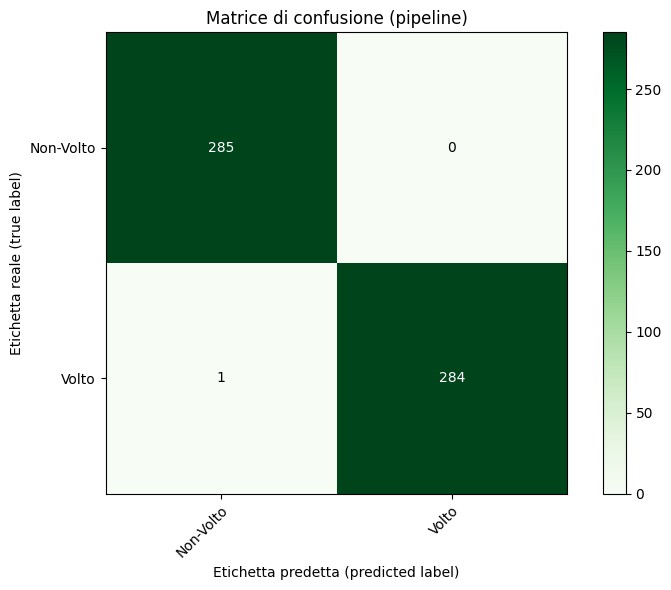


Interpretazione della matrice di confusione:
  Non-Volto (Reale) vs Non-Volto (Predetto) [true negative - TN]: 285
  Non-Volto (Reale) vs Volto (Predetto) [false positive - FP]: 0
  Volto (Reale) vs Non-Volto (Predetto) [false negative - FN]: 1
  Volto (Reale) vs Volto (Predetto) [true positive - TP]: 284


In [131]:
print("\nMatrice di confusione per la pipeline...")

#nomi classi
class_names = ['Non-Volto', 'Volto']

#calcolo matrice di confusione
cm_pipeline = confusion_matrix(y_test_labels, y_pred_pipeline)
print("\nMatrice di Confusione (formato array NumPy):")
print(cm_pipeline)

#plot matrice di confusione
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_pipeline, interpolation='nearest', cmap=plt.cm.Greens)
ax.figure.colorbar(im, ax=ax)

# etichette con nomi delle classi
ax.set(xticks=np.arange(cm_pipeline.shape[1]),
        yticks=np.arange(cm_pipeline.shape[0]),
        xticklabels=class_names, yticklabels=class_names,
        title='Matrice di confusione (pipeline)',
        ylabel='Etichetta reale (true label)',
        xlabel='Etichetta predetta (predicted label)')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

#valori numerici all'interno di ogni cella della matrice
thresh = cm_pipeline.max() / 2.
for i in range(cm_pipeline.shape[0]):
    for j in range(cm_pipeline.shape[1]):
        ax.text(j, i, format(cm_pipeline[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_pipeline[i, j] > thresh else "black")

fig.tight_layout()
plt.show()

print("\nInterpretazione della matrice di confusione:")
print(f"  {class_names[0]} (Reale) vs {class_names[0]} (Predetto) [true negative - TN]: {cm_pipeline[0, 0]}")
print(f"  {class_names[0]} (Reale) vs {class_names[1]} (Predetto) [false positive - FP]: {cm_pipeline[0, 1]}")
print(f"  {class_names[1]} (Reale) vs {class_names[0]} (Predetto) [false negative - FN]: {cm_pipeline[1, 0]}")
print(f"  {class_names[1]} (Reale) vs {class_names[1]} (Predetto) [true positive - TP]: {cm_pipeline[1, 1]}")


Costruzione learning curves per 'model_pipeline_trained'...


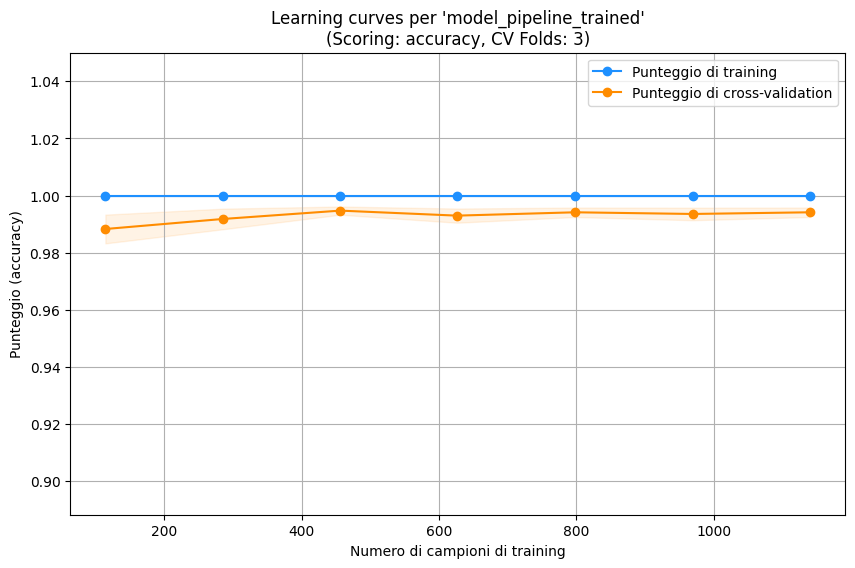

In [132]:
print("\nCostruzione learning curves per 'model_pipeline_trained'...")

train_sizes_proportions = np.linspace(0.1, 1.0, 7) # Es: [0.1, 0.25, 0.5, 0.75, 1.0] o più punti

cv_folds_lc = 3

scoring_metric_lc = 'accuracy'


train_sizes_abs, train_scores, test_scores = learning_curve(
    estimator=model_pipeline_trained,  #modello/pipeline
    X=X_train_patches,    #feature del training set originale
    y=y_train_labels,   #etichette del training set originale
    train_sizes=train_sizes_proportions, #proporzioni del training set da usare
    cv=cv_folds_lc,
    scoring=scoring_metric_lc,
    n_jobs=-1,
    random_state=1996
)

#calcola la media e la deviazione standard degli score di training e di test (cross-validation)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#Learning Curves
plt.figure(figsize=(10, 6))
plt.title(f"Learning curves per 'model_pipeline_trained'\n(Scoring: {scoring_metric_lc}, CV Folds: {cv_folds_lc})")
plt.xlabel("Numero di campioni di training")
plt.ylabel(f"Punteggio ({scoring_metric_lc})")
plt.grid(True)

#curva di training
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="dodgerblue", label="Punteggio di training")
plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                  train_scores_mean + train_scores_std, alpha=0.1, color="dodgerblue")

#curva di cross-validation (test)
plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="darkorange", label="Punteggio di cross-validation")
plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                  test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")

plt.legend(loc="best")
plt.ylim(bottom=max(0, np.min(test_scores_mean) - 0.1), top=1.05)
plt.show()




###4.2 Fine tuning e valutazione (miglior modello)

In [133]:
#richiede circa 3 minuti
print("\nFine tuning degli iperparametri...")

#definizione pipeline base
#i parametri iniziali qui verranno sovrascritti dalla ricerca.
pipeline_to_tune = Pipeline([
    ('hog_transformer', HOGTransformer()),
    ('svc_classifier', LinearSVC(penalty='l2', dual='auto', random_state=1996, max_iter=5000))
])

#definizione dello spazio dei parametri da esplorare
param_distributions = {
    #parametri per HOGTransformer
    'hog_transformer__orientations': [8, 9, 10],
    'hog_transformer__pixels_per_cell': [(6, 6), (8, 8), (10, 10)],
    'hog_transformer__cells_per_block': [(2, 2), (3, 3)],
    'hog_transformer__block_norm': ['L2-Hys', 'L1-sqrt'],
    'hog_transformer__transform_sqrt': [True, False],

    #parametri per LinearSVC
    'svc_classifier__C': loguniform(0.001, 100.0),
    'svc_classifier__loss': ['hinge', 'squared_hinge'],
    'svc_classifier__class_weight': ['balanced', None]
}

#inizializzazione RandomizedSearchCV
n_iterations_search = 15
cv_folds = 3

random_search = RandomizedSearchCV(
    estimator=pipeline_to_tune,
    param_distributions=param_distributions,
    n_iter=n_iterations_search,
    cv=cv_folds,
    scoring='f1_weighted', #f1_weighted è spesso una buona scelta per problemi di classificazione
    random_state=1996,
    n_jobs=-1,
    verbose=2
)

#esecuzione ricerca iperparametri sul training set
print(f"\nRandomizedSearchCV con {n_iterations_search} iterazioni e {cv_folds} fold di CV...")

random_search.fit(X_train_patches, y_train_labels)

#migliori parametri e il miglior score
print("\n===================================================")
print("RISULTATI FINE TUNING:")
print("===================================================")
print(f"Migliori parametri trovati: {random_search.best_params_}")
print(f"Miglior punteggio CV ({random_search.scoring}): {random_search.best_score_:.4f}")

#pipeline migliore (già ri-addestrata sull'intero X_train_patches con i best_params_)
best_tuned_pipeline = random_search.best_estimator_

#valutazione pipeline ottimizzata sul test set
print("\nValutazione della pipeline ottimizzata sul test set:")
y_pred_tuned_pipeline = best_tuned_pipeline.predict(X_test_patches)

print(f"\nAccuracy (pipeline ottimizzata) sul test set: {accuracy_score(y_test_labels, y_pred_tuned_pipeline):.4f}")
print("\nClassification report (pipeline ottimizzata) sul test set:")
print(classification_report(y_test_labels, y_pred_tuned_pipeline, target_names=['Non-Volto', 'Volto']))

#aggiorna il modello principale con quello ottimizzato
model_pipeline_trained = best_tuned_pipeline
print("\n'model_pipeline_trained' è stato aggiornato con il modello ottimizzato da RandomizedSearchCV.")




Fine tuning degli iperparametri...

RandomizedSearchCV con 15 iterazioni e 3 fold di CV...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
  HOGTransformer: trasformazione di 1710 patch...
  HOGTransformer: caratteristiche estratte con forma (1710, 5760)

RISULTATI FINE TUNING:
Migliori parametri trovati: {'hog_transformer__block_norm': 'L2-Hys', 'hog_transformer__cells_per_block': (3, 3), 'hog_transformer__orientations': 10, 'hog_transformer__pixels_per_cell': (8, 8), 'hog_transformer__transform_sqrt': False, 'svc_classifier__C': np.float64(26.245800050491326), 'svc_classifier__class_weight': None, 'svc_classifier__loss': 'squared_hinge'}
Miglior punteggio CV (f1_weighted): 0.9942

Valutazione della pipeline ottimizzata sul test set:
  HOGTransformer: trasformazione di 570 patch...
  HOGTransformer: caratteristiche estratte con forma (570, 5760)

Accuracy (pipeline ottimizzata) sul test set: 0.9982

Classification report (pipeline ottimizzata) sul test set:
             


Matrice di confusione per la pipeline...

Matrice di confusione (formato array numpy):
[[285   0]
 [  1 284]]


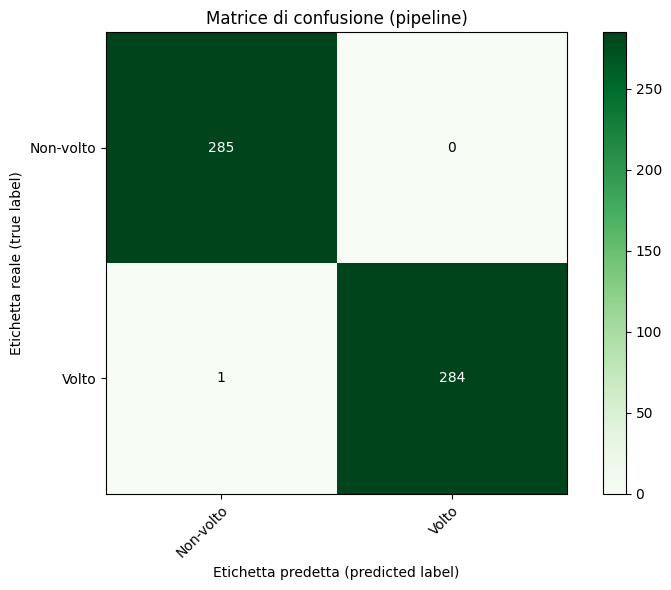


Interpretazione della matrice di confusione:
  Non-volto (Reale) vs Non-volto (Predetto) [true negative - TN]: 285
  Non-volto (Reale) vs Volto (Predetto) [false positive - FP]: 0
  Volto (Reale) vs Non-volto (Predetto) [false negative - FN]: 1
  Volto (Reale) vs Volto (Predetto) [true positive - TP]: 284


In [134]:
print("\nMatrice di confusione per la pipeline...")

#nomi classi
class_names = ['Non-volto', 'Volto']

#calcolo matrice di confusione
cm_pipeline = confusion_matrix(y_test_labels, y_pred_pipeline)
print("\nMatrice di confusione (formato array numpy):")
print(cm_pipeline)

#plot matrice di confusione
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_pipeline, interpolation='nearest', cmap=plt.cm.Greens)
ax.figure.colorbar(im, ax=ax)

# etichette con nomi delle classi
ax.set(xticks=np.arange(cm_pipeline.shape[1]),
        yticks=np.arange(cm_pipeline.shape[0]),
        xticklabels=class_names, yticklabels=class_names,
        title='Matrice di confusione (pipeline)',
        ylabel='Etichetta reale (true label)',
        xlabel='Etichetta predetta (predicted label)')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

#valori numerici all'interno di ogni cella della matrice
thresh = cm_pipeline.max() / 2.
for i in range(cm_pipeline.shape[0]):
    for j in range(cm_pipeline.shape[1]):
        ax.text(j, i, format(cm_pipeline[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_pipeline[i, j] > thresh else "black")

fig.tight_layout()
plt.show()

print("\nInterpretazione della matrice di confusione:")
print(f"  {class_names[0]} (Reale) vs {class_names[0]} (Predetto) [true negative - TN]: {cm_pipeline[0, 0]}")
print(f"  {class_names[0]} (Reale) vs {class_names[1]} (Predetto) [false positive - FP]: {cm_pipeline[0, 1]}")
print(f"  {class_names[1]} (Reale) vs {class_names[0]} (Predetto) [false negative - FN]: {cm_pipeline[1, 0]}")
print(f"  {class_names[1]} (Reale) vs {class_names[1]} (Predetto) [true positive - TP]: {cm_pipeline[1, 1]}")


Learning curves per 'model_pipeline_trained'...


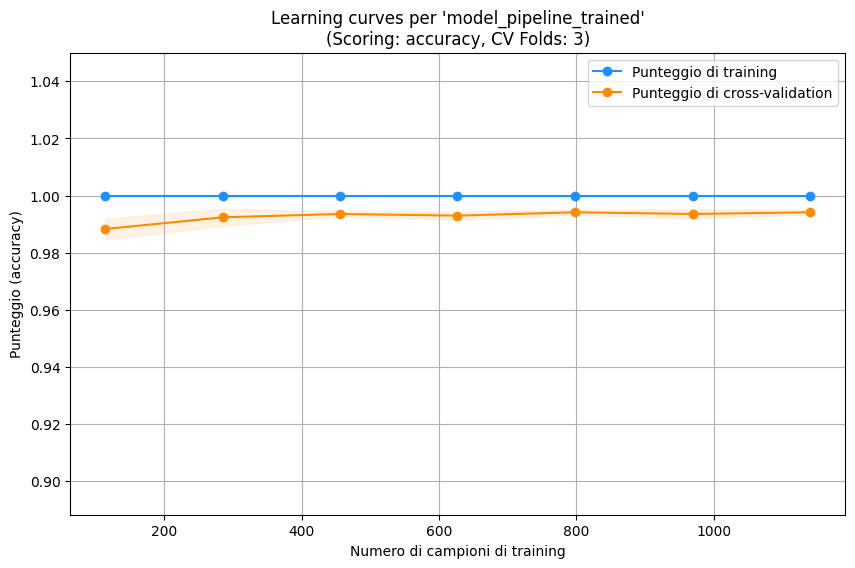

In [135]:
print("\nLearning curves per 'model_pipeline_trained'...")

train_sizes_proportions = np.linspace(0.1, 1.0, 7)

cv_folds_lc = 3

scoring_metric_lc = 'accuracy'

train_sizes_abs, train_scores, test_scores = learning_curve(
    estimator=model_pipeline_trained, #modello/pipeline aggiornato --------IMPORTANTE!!!! Il resto del codice è come sopra
    X=X_train_patches,
    y=y_train_labels,
    train_sizes=train_sizes_proportions,
    cv=cv_folds_lc,
    scoring=scoring_metric_lc,
    n_jobs=-1,
    random_state=1996
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title(f"Learning curves per 'model_pipeline_trained'\n(Scoring: {scoring_metric_lc}, CV Folds: {cv_folds_lc})")
plt.xlabel("Numero di campioni di training")
plt.ylabel(f"Punteggio ({scoring_metric_lc})")
plt.grid(True)

plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="dodgerblue", label="Punteggio di training")
plt.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                  train_scores_mean + train_scores_std, alpha=0.1, color="dodgerblue")

plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="darkorange", label="Punteggio di cross-validation")
plt.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                  test_scores_mean + test_scores_std, alpha=0.1, color="darkorange")

plt.legend(loc="best")
plt.ylim(bottom=max(0, np.min(test_scores_mean) - 0.1), top=1.05)
plt.show()


#5 Funzioni per il rilevamento: Image Pyramid, Sliding Window e NMS
In questa sezione vengono definite tre funzioni cruciali che sono componenti fondamentali di molti sistemi di rilevazione di oggetti e di volti. Tali funzioni non dipendono dal modello specifico (HOG+SVM in questo caso) ma forniscono la meccanica per scansionare un'immagine e raffinare le rilevazioni.
<br>
- Image Pyramid<br>
Questa funzione ha lo scopo di generare una "piramide di immagini". L'idea di fondo è quella di creare versioni progressivamente più piccole dell'immagine originale. Ciò permette al rilevatore (che è addestrato per rilevare /volti di una dimensione definita da PATCH_SIZE) di trovare oggetti/volti a diverse scale nell'immagine originale. Senza una piramide, un volto grande potrebbe essere troppo grande per la finestra di rilevamento e un volto piccolo potrebbe essere troppo piccolo e privo di dettagli.
- Sliding Window<br>
Con questa funzione vengono generate "finestre scorrevoli" (patch) di una dimensione fissa (window_size_tuple) che si muovono attraverso un'immagine con un certo passo (step_size_tuple). Questa è una tecnica base per esaminare diverse porzioni di un'immagine.
- Non Maximum Suppression<br>
Quando si usa una finestra scorrevole, è probabile che lo stesso oggetto/un volto venga rilevato più volte con bounding box leggermente diverse e punteggi di confidenza variabili. NMS è una tecnica per eliminare le rilevazioni ridondanti e mantenere solo la bounding box "migliore" per ciascun oggetto.
<br>
<br>
OSSERVAZIONI: (a) nella sostanza, queste funzioni gestiscono la logica di scansione dell'immagine; (b) la funzione extract_hog_features definita globalmente non è più necessaria perché la pipeline si occupa dell'estrazione HOG.

###5.1 image_pyramid

In [136]:
def image_pyramid(image, scale_factor=1.25, min_size_tuple=PATCH_SIZE):
    """Genera una piramide di immagini."""
    yield image
    current_h, current_w = image.shape[:2]
    min_h, min_w = min_size_tuple

    while True:
        #calcola le nuove dimensioni dell'immagine riducendole del scale_factor
        new_w = int(current_w / scale_factor)
        new_h = int(current_h / scale_factor)
        if new_w < min_w or new_h < min_h:
            break
        image = transform.resize(image, (new_h, new_w), anti_aliasing=True, mode='reflect')
        yield image
        current_h, current_w = new_h, new_w

###5.2 sliding_window

In [137]:
def sliding_window(image, window_size_tuple, step_size_tuple):
    """Genera finestre che scorrono sull'immagine."""
    img_h, img_w = image.shape[:2]
    win_h, win_w = window_size_tuple
    step_w, step_h = step_size_tuple

    for y in range(0, img_h - win_h + 1, step_h):
        for x in range(0, img_w - win_w + 1, step_w):
            yield (x, y, image[y:y + win_h, x:x + win_w])

###5.3 non_maximum_suppression

In [138]:
def non_maximum_suppression(boxes_array, scores_array, overlap_threshold=0.3):
    """Applica Non-Maximum Suppression alle bounding box."""
    if len(boxes_array) == 0:
        return []

    x1 = boxes_array[:, 0]
    y1 = boxes_array[:, 1]
    x2 = boxes_array[:, 2]
    y2 = boxes_array[:, 3]
    areas = (x2 - x1) * (y2 - y1)

    #ordina per score
    order = scores_array.argsort()[::-1]

    keep_indices = []
    while order.size > 0:
        i = order[0]
        keep_indices.append(i)

        #calcola intersezioni con le box rimanenti
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w_inter = np.maximum(0, xx2 - xx1)
        h_inter = np.maximum(0, yy2 - yy1)
        intersection = w_inter * h_inter

        iou = intersection / (areas[i] + areas[order[1:]] - intersection + 1e-5) #epsilon per stabilità

        #mantiene solo le box con intersezione su unione (IoU) minore della soglia
        inds_to_keep = np.where(iou <= overlap_threshold)[0]
        order = order[inds_to_keep + 1] #+1 perché iou è calcolato rispetto a order[1:]

    return boxes_array[keep_indices].astype("int")

#6 Rilevamento volti
In questa sezione viene definita la funzione principale detect_faces, la quale gestisce l'intero processo di rilevamento dei volti in un'immagine utilizzando la pipeline addestrata e ottimizzata in precedenza.<br>
<br>
Più precisamente, la funzione esegue i seguenti step:
- Preparazione iniziale dell'immagine:<br>
// L'immagine in input viene convertita in scala di grigi.<br>
// Vengono normalizzati i valori di intensità dei pixel dell'immagine in scala di grigi (generalmente tra 0 e 1).
- Configurazione dei parametri di scansione:<br>
// Vengono inizializzate le liste per memorizzare le coordinate dei riquadri di rilevamento e i relativi punteggi di confidenza.<br>
// Vengono calcolati la dimensione minima consentita per le immagini nella piramide di scale.<br>
// Viene calcolato il passo (orizzontale e verticale) per la finestra scorrevole.<br>
// Viene inizializzato un moltiplicatore per tracciare la scala corrente rispetto all'immagine originale.
-Scansione multiscala dell'immagine:<br>
// La scansione itera attraverso diversi livelli di una piramide di immagini (versioni ridimensionate dell'immagine originale) e per ogni immagine scalata: aggiorna il moltiplicatore di scala, salta l'immagine se è diventata più piccola della dimensione della patch di input e viene applicata la Sliding Window.<br>
// La Sliding Window itera su diverse porzioni (patch) dell'immagine scalata usando una finestra scorrevole e per ogni patch estratta dalla finestra: avviene la classificazione della patch (ottiene un punteggio di confidenza dalla pipeline addestrata per determinare se la patch contiene un volto) e la memorizzazione delle rilevazioni positive.<br>
// Se il punteggio di una patch supera la soglia di confidenza (detection_confidence_threshold), allora quella patch è considerata una rilevazione positiva. Le sue coordinate e dimensioni vengono convertite dalla scala corrente a quella dell'immagine originale, e il riquadro di delimitazione risultante, insieme al punteggio, viene memorizzato.
- Controllo rilevazioni iniziali:<br>
// Se non viene trovata alcuna potenziale rilevazione dopo la scansione allora viene restituita una lista vuota.
- Applicazione della Non Maximum Suppression (NMS):<br>
// Viene applicata la NMS alle rilevazioni grezze per eliminare i riquadri di delimitazione ridondanti e sovrapposti mantenendo solo quelli più significativi.
- Restituzione dei risultati finali:<br>
// Le coordinate dei riquadri di delimitazione finali vengono convertite in una lista.

In [139]:
def detect_faces(image_to_scan,
                 fitted_pipeline, #pipeline addestrata (HOG+SVC)
                 input_patch_size=PATCH_SIZE,
                 pyramid_scale=1.3,
                 pyramid_min_size_ratio_to_patch=1.0, #dimensione minima piramide rispetto a patch_size
                 window_step_factor=0.20, #step come frazione di patch_size
                 nms_iou_threshold=0.25,
                 detection_confidence_threshold=1.0): #soglia per SVM decision_function
    """
    Rileva i volti in un'immagine utilizzando la pipeline addestrata.
    """

    #step 1: preparazione immagine
    if image_to_scan.ndim == 3 and image_to_scan.shape[2] == 3: #RGB
        img_gray = color.rgb2gray(image_to_scan)
    elif image_to_scan.ndim == 3 and image_to_scan.shape[2] == 4: #RGBA
        img_gray = color.rgb2gray(color.rgba2rgb(image_to_scan))
    elif image_to_scan.ndim == 2: #già grayscale
        img_gray = image_to_scan
    else:
        raise ValueError(f"Formato immagine non supportato: {image_to_scan.shape}")

    img_gray = exposure.rescale_intensity(img_gray, out_range=(0, 1)) #normalizza a [0,1]

    detected_boxes_at_scale = []
    associated_scores = []

    #definizione dimensione minima per la piramide basata sulla patch size
    min_pyramid_h = int(input_patch_size[0] * pyramid_min_size_ratio_to_patch)
    min_pyramid_w = int(input_patch_size[1] * pyramid_min_size_ratio_to_patch)

    #definizione step della sliding window
    step_size_w = int(input_patch_size[1] * window_step_factor)
    step_size_h = int(input_patch_size[0] * window_step_factor)
    actual_step_size = (step_size_w, step_size_h)

    current_scale_multiplier = 1.0 #fattore per riportare le coordinate alla scala originale

    #step 2: image pyramid
    for i_scale, scaled_img in enumerate(image_pyramid(img_gray,
                                                     scale_factor=pyramid_scale,
                                                     min_size_tuple=(min_pyramid_h, min_pyramid_w))):

        if i_scale > 0: #aggiorna moltiplicatore di scala (dopo la prima iterazione)
            current_scale_multiplier *= pyramid_scale

        print(f"  Processing scale {i_scale + 1}, img shape: {scaled_img.shape}, "
              f"coord_multiplier: {current_scale_multiplier:.2f}")

        if scaled_img.shape[0] < input_patch_size[0] or scaled_img.shape[1] < input_patch_size[1]:
            print(f"    Scala troppo piccola ({scaled_img.shape}) per patch ({input_patch_size}), skippo.")
            continue

        #step 3: sliding window sulla scaled_img
        for (x, y, current_window_patch) in sliding_window(scaled_img,
                                                            input_patch_size,
                                                            actual_step_size):

            if current_window_patch.shape[0] != input_patch_size[0] or \
               current_window_patch.shape[1] != input_patch_size[1]:
                continue #patch di dimensione non corretta

            #estrazione score dalla pipeline.
            #decision_function restituisce un array, quindi viene preso il primo elemento.
            score = fitted_pipeline.decision_function([current_window_patch])[0]
            #la pipeline internamente chiamerà HOGTransformer.transform e poi SVC.decision_function

            if score > detection_confidence_threshold:
                #trasformazione coordinate della patch rilevata alla scala dell'immagine originale
                original_x1 = int(x * current_scale_multiplier)
                original_y1 = int(y * current_scale_multiplier)
                #larghezza e altezza della patch nella scala originale
                original_patch_w = int(input_patch_size[1] * current_scale_multiplier)
                original_patch_h = int(input_patch_size[0] * current_scale_multiplier)
                original_x2 = original_x1 + original_patch_w
                original_y2 = original_y1 + original_patch_h

                detected_boxes_at_scale.append((original_x1, original_y1, original_x2, original_y2))
                associated_scores.append(score)
                # se interessa un print preciso ---- print(f"    Rilevato potenziale volto a ({x},{y}) score: {score:.2f} -> Orig: ({original_x1},{original_y1})")

    if not detected_boxes_at_scale:
        print("Nessun volto grezzo rilevato prima di NMS.")
        return []

    #step 4: non maximum suppression
    print(f"\nApplicazione NMS a {len(detected_boxes_at_scale)} rilevazioni grezze...")
    final_bounding_boxes = non_maximum_suppression(np.array(detected_boxes_at_scale),
                                                   np.array(associated_scores),
                                                   overlap_threshold=nms_iou_threshold)

    print(f"Rilevati {len(final_bounding_boxes)} volti dopo NMS.")
    return final_bounding_boxes.tolist() #restituisce una lista di liste/tuple

#7 Test di rilevamento volti
In questa sezione si vuole testare il sistema di rilevamento volti su un'immagine di esempio e a visualizzarne i risultati. Viene inoltre inclusa una sezione (commentata) per testare il sistema con un'immagine caricata dall'utente.
<br>
<br>
Più nel dettaglio:<br>
- Definizione della funzione di visualizzazione<br>
Viene definita la funzione display_image_with_boxes che ha lo scopo di mostrare un'immagine e disegnare su di essa dei rettangoli (bounding box) che indicano e delimitano i volti rilevati.
- Test del rilevamento su un'immagine di esempio<br>
Viene caricata un'immagine di test dalla libreria skimage.data e viene chiamata la funzione detect_faces, definita in precedenza, per trovare i volti nell'immagine.
Infine vengono visualizzati i risultati: se vengono trovati dei volti (detected_boxes_astronaut non è vuota) allora la funzione display_image_with_boxes viene usata per mostrare l'immagine dell'astronauta con i riquadri dei volti rilevati e un titolo appropriato; se invece non vengono trovati volti allora viene stampato un messaggio e mostrata l'immagine originale senza riquadri, con un titolo che indica l'assenza di rilevamenti.
- Test con immagine caricata dall'utente (implementata nella parte commentata)<br>
Questa parte del codice è commentata. Permette all'utente di caricare un'immagine dal proprio computer, convertire l'immagine caricata nel formato corretto, eseguire la funzione detect_faces su questa immagine personalizzata e visualizzare i risultati (immagine con bounding box o messaggio di nessun volto trovato) usando la stessa logica precedentemente detta.


Immagine di test caricata, shape: (512, 512, 3)
  Processing scale 1, img shape: (512, 512), coord_multiplier: 1.00
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  HOGTransformer: trasformazione di 1 patch...
  HOGTransformer: caratteristiche estratte con forma (1, 5760)
  H

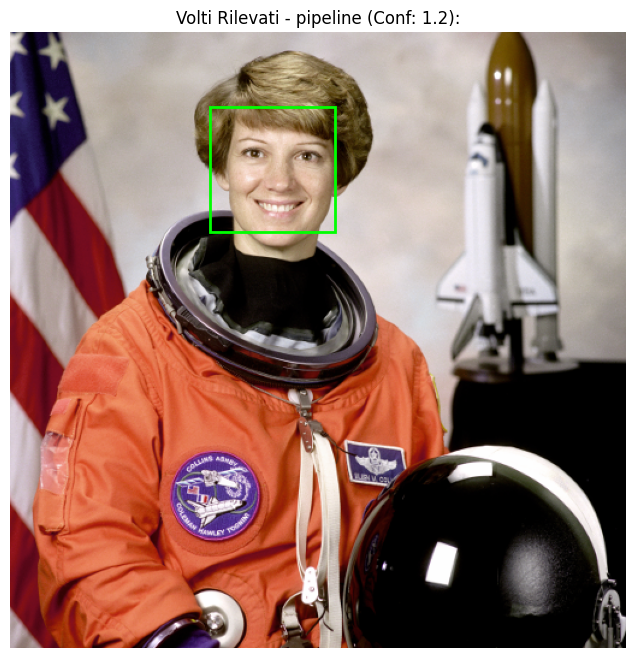


Coordinate dei volti rilevati nell'immagine(Conf: 1.2):
  Volto 1: x1=166, y1=62, x2=270, y2=166 (larghezza: 104, altezza: 104)


In [141]:
def display_image_with_boxes(image_to_display, boxes_list, title="Detected Faces"):
    """Mostra l'immagine con i bounding box disegnati."""
    plt.figure(figsize=(10, 8))

    if image_to_display.ndim == 2:
        plt.imshow(image_to_display, cmap='gray')
    else:
        plt.imshow(image_to_display)

    plt.title(title)
    ax = plt.gca()

    for (x1, y1, x2, y2) in boxes_list:
        rect_w = x2 - x1
        rect_h = y2 - y1
        rect = plt.Rectangle((x1, y1), rect_w, rect_h,
                             fill=False, edgecolor='lime', linewidth=2)
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()

#test con un'immagine di esempio
test_image_astronaut = data.astronaut()
print(f"\nImmagine di test caricata, shape: {test_image_astronaut.shape}")



#parametri di rilevamento
detected_boxes_astronaut = detect_faces(
    image_to_scan=test_image_astronaut,
    fitted_pipeline=model_pipeline_trained, #pipeline
    input_patch_size=PATCH_SIZE,
    pyramid_scale=1.3,
    pyramid_min_size_ratio_to_patch=1.0,
    window_step_factor=0.20,
    nms_iou_threshold=0.2,
    detection_confidence_threshold=1.2 #questo parametro  può essere mosso per regolare la sensibilità del sistema
)
# NOTA PER LETTORE:
#detect_faces usa la pipeline addestrata
#model_pipeline_trained è la pipeline che non è quella solo addestrata ma quella addestrata e tunata!!!!
#se si vuole testare il print delle coordinate in caso di più volti allora detection_confidence_threshold=1.2 (rilevatore più debole)

if detected_boxes_astronaut:
    display_image_with_boxes(test_image_astronaut, detected_boxes_astronaut,
              title=f"Volti Rilevati - pipeline (Conf: 1.2):") #1.2 è la soglia impostata nei parametri sopra
    print(f"\nCoordinate dei volti rilevati nell'immagine(Conf: 1.2):") #1.2 è la soglia impostata nei parametri sopra
    for i, box in enumerate(detected_boxes_astronaut):
        x1, y1, x2, y2 = box
        print(f"  Volto {i+1}: x1={x1}, y1={y1}, x2={x2}, y2={y2} (larghezza: {x2-x1}, altezza: {y2-y1})")
else:
    print("Nessun volto trovato nell'immagine di test.")
    plt.imshow(test_image_astronaut)
    plt.title("Nessun volto rilevato - Pipeline")
    plt.axis('off')
    plt.show()

#Test con immagine caricata dall'utente

#from google.colab import files
#import cv2 #leggere l'immagine in modo robusto

#print("\nCarica un'immagine per il test (opzionale):")
#uploaded = files.upload()
#f uploaded:
#    file_name = list(uploaded.keys())[0]
#    print(f"File caricato: {file_name}")

#    img_bytes = uploaded[file_name]
#    nparr = np.frombuffer(img_bytes, np.uint8)
#    custom_image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
#    custom_image_rgb = cv2.cvtColor(custom_image, cv2.COLOR_BGR2RGB)

#    print("Rilevamento volti sull'immagine personalizzata...")
#    custom_detected_boxes = detect_faces(
#        image_to_scan=custom_image_rgb,
#        fitted_pipeline=model_pipeline_trained,
#        input_patch_size=PATCH_SIZE,
#        detection_confidence_threshold=1.0
#    )
#    if custom_detected_boxes:
#        display_image_with_boxes(custom_image_rgb, custom_detected_boxes,
#                                title="Volti rilevati (immagine personalizzata) - Pipeline")
#    else:
#        print("Nessun volto trovato nell'immagine personalizzata.")
#        plt.imshow(custom_image_rgb)
#        plt.title("Nessun volto rilevato (immagine personalizzata) - Pipeline")
#        plt.axis('off')
#        plt.show()



NOTA PER IL LETTORE: i molteplici print sono di debug inseriti all'interno del metodo transform della classe HOGTransformer e all'interno del ciclo di detect_faces. Possono essere eliminati ma li lascio in modo da rilevare eventuali errori con altre immagini